Loading data...

Exploring data...
Training data shape: (61609, 61)

Feature statistics:


,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,56733.000000,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,0.481647,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.251526,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,0.287000,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,0.477000,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,0.677000,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,1.000000,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000



Missing values:


,Missing Values,Percentage
emotional_charge_2,2442,3.963707
groove_efficiency_1,180,0.292165
beat_frequency_1,386,0.626532
organic_texture_2,383,0.621662
composition_label_0,2949,4.786638
harmonic_scale_1,3305,5.364476
intensity_index_0,5971,9.691766
duration_ms_0,1289,2.092227
album_name_length,9594,15.572400
beat_frequency_0,9731,15.794770


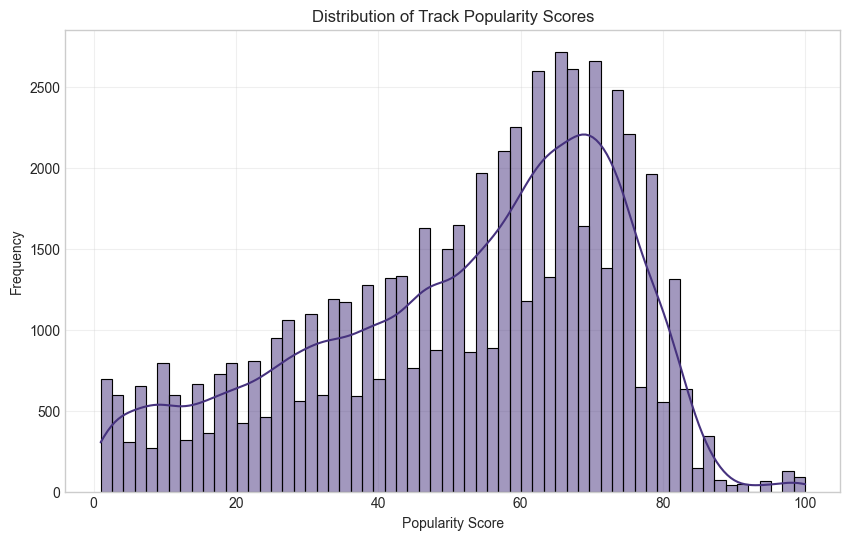

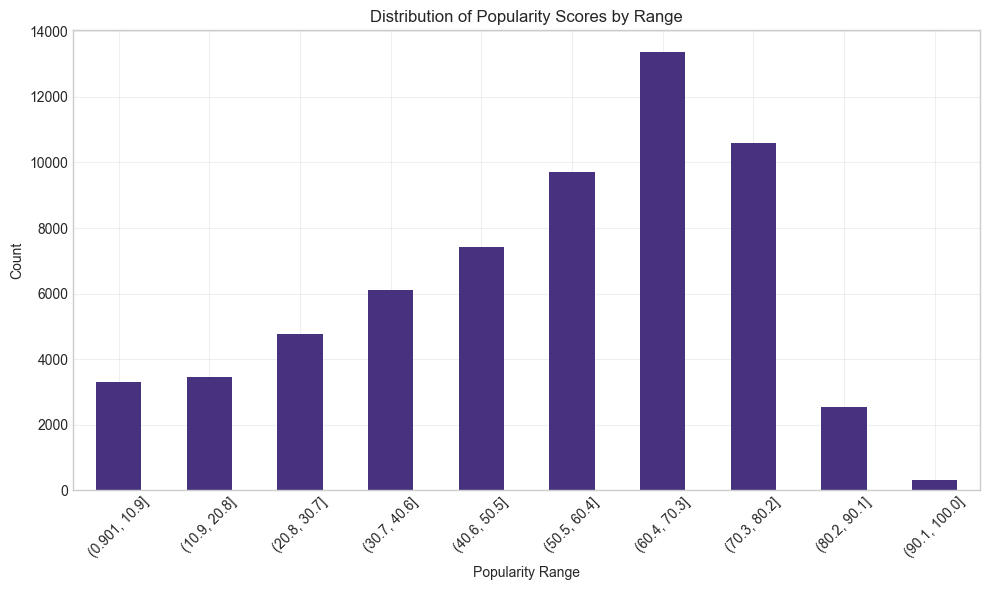

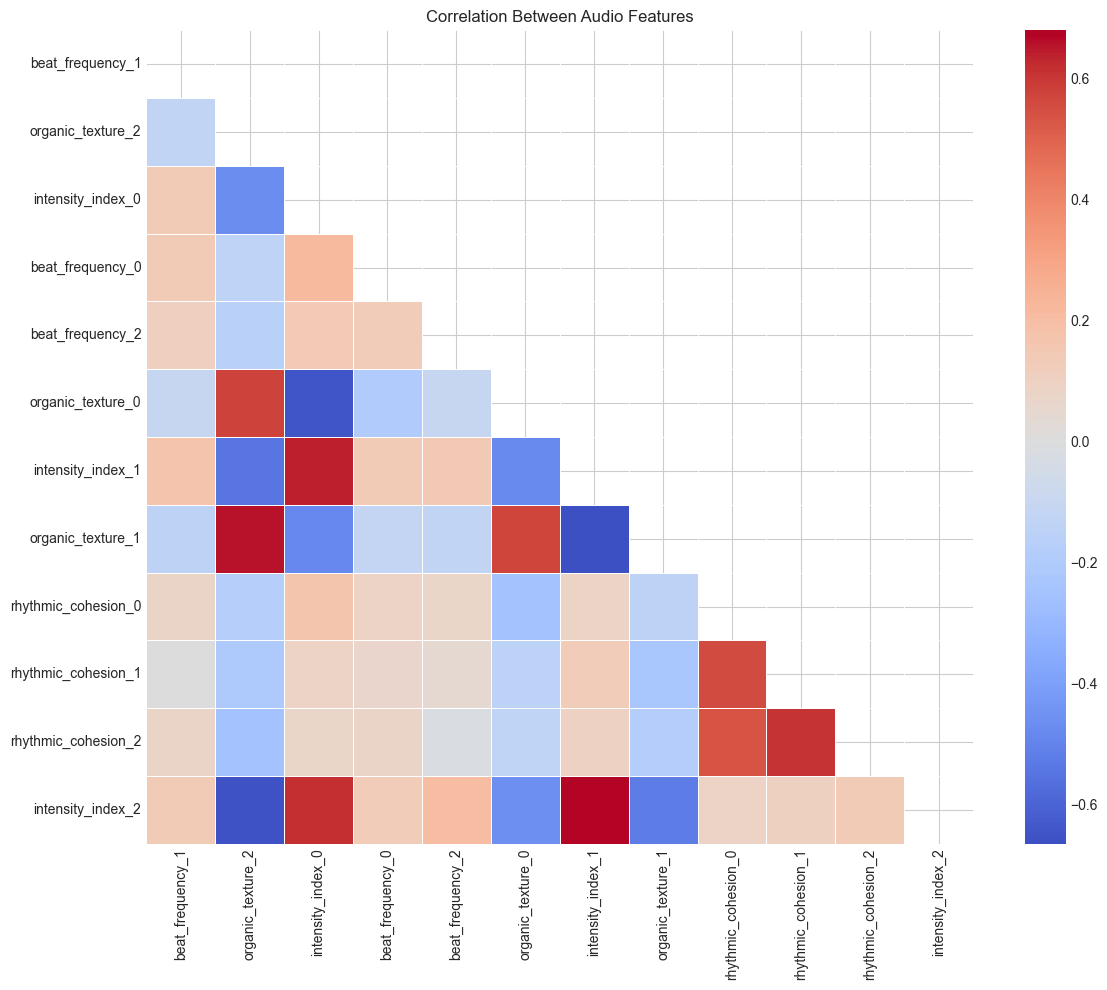

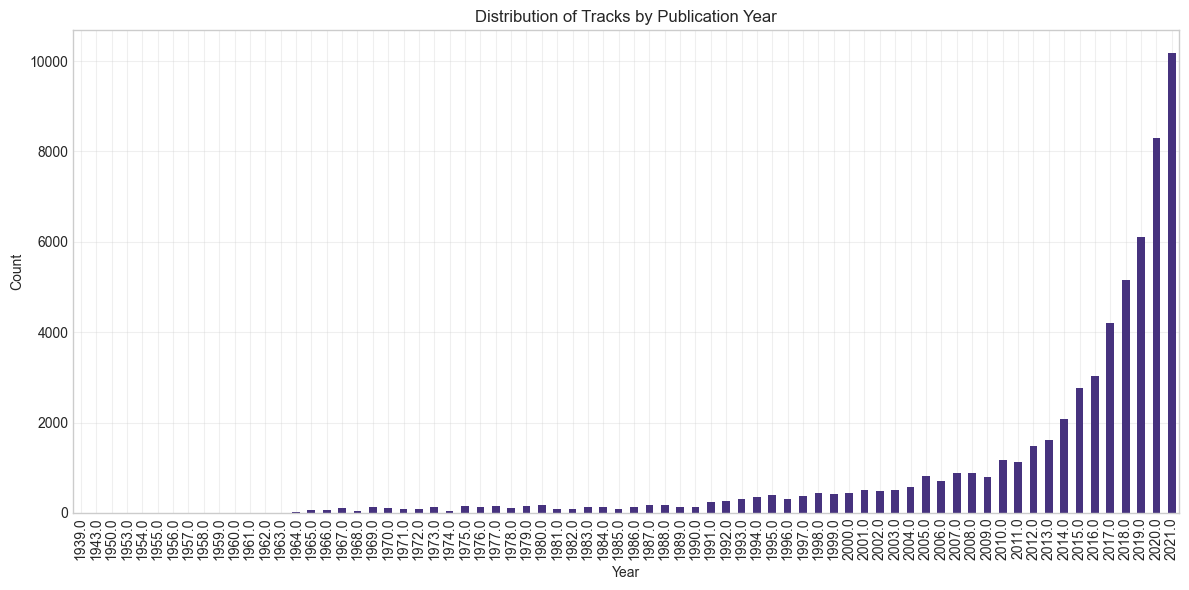


Preprocessing data...

Handling outliers...


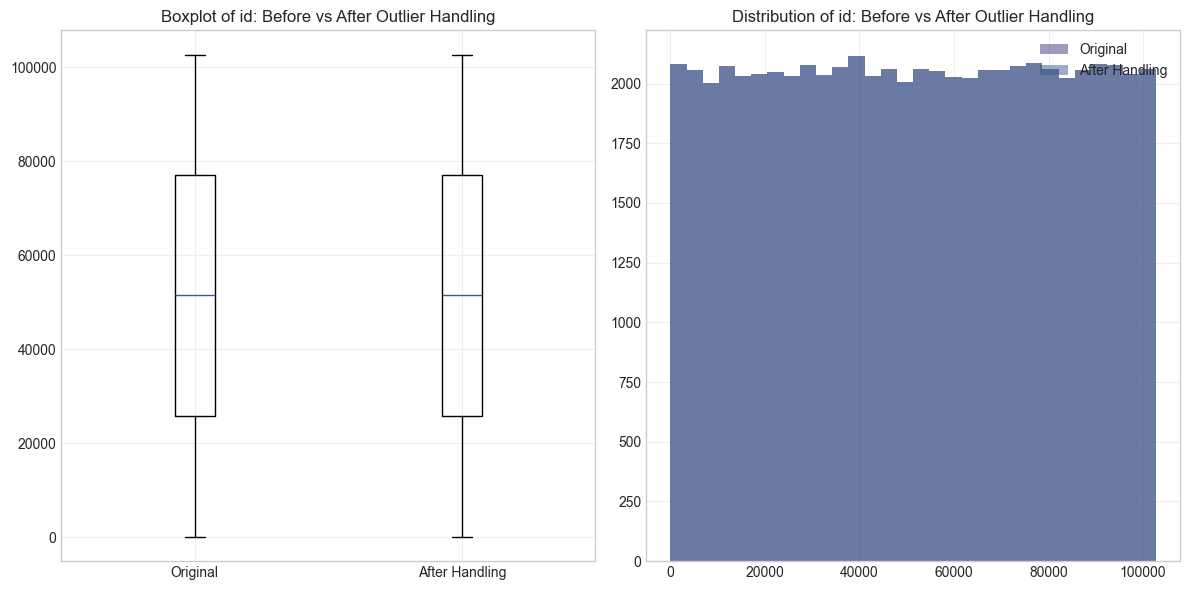

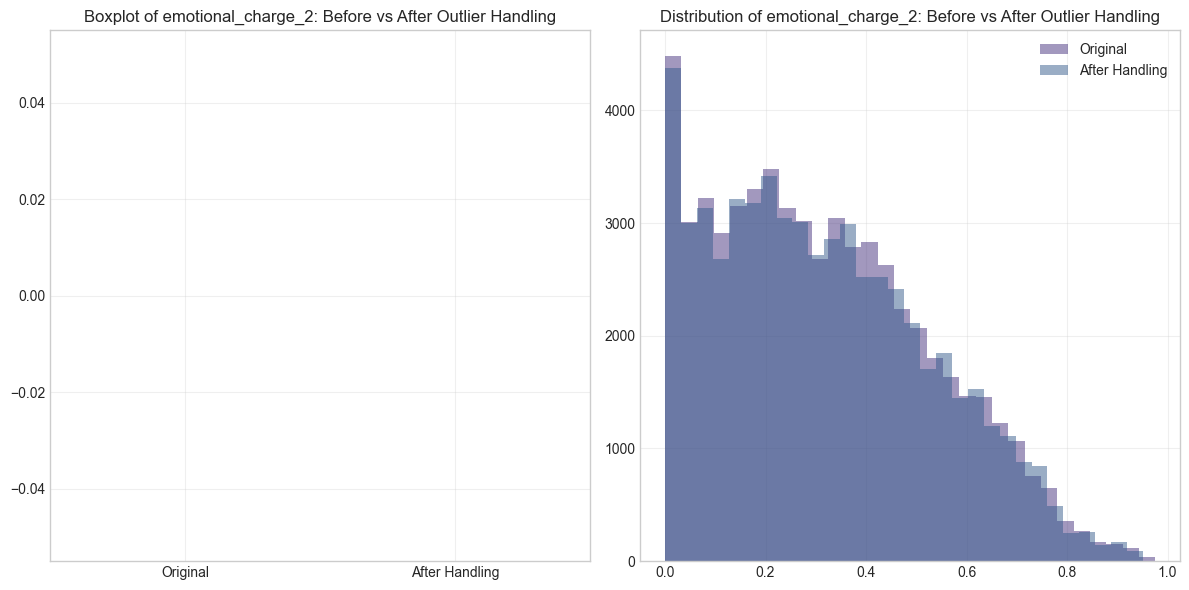

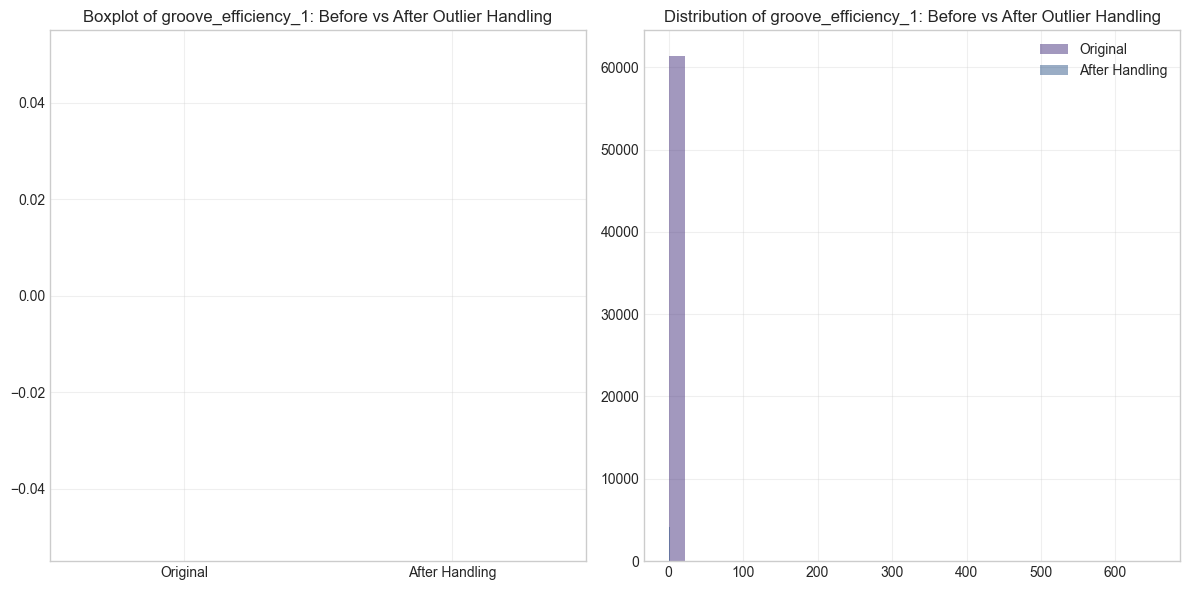


Splitting data...

Building model pipeline...

Training model...

Evaluating model...
Validation RMSE: 10.9200
Validation MAE: 6.8385
Validation R^2: 0.7440


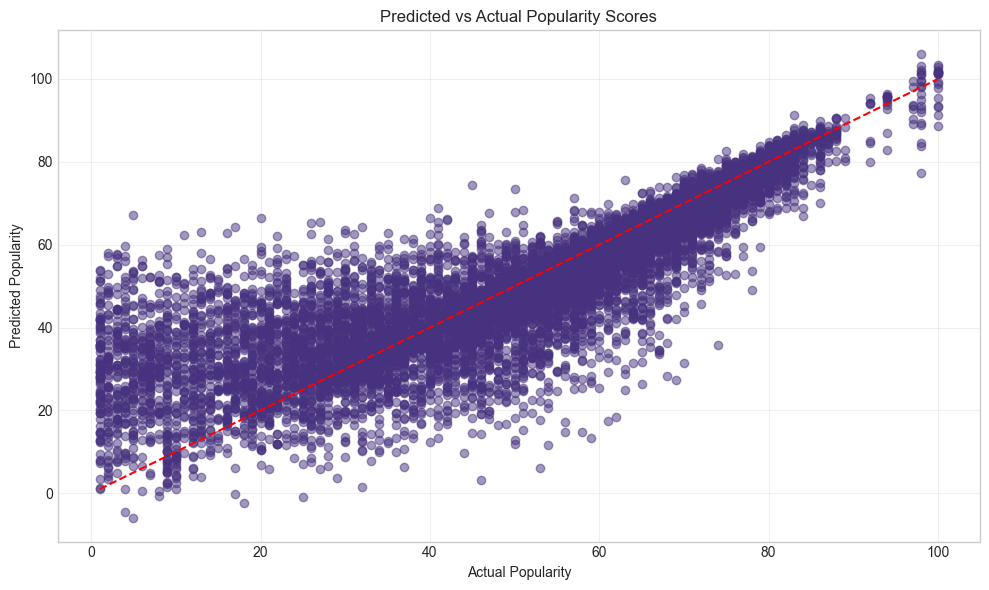

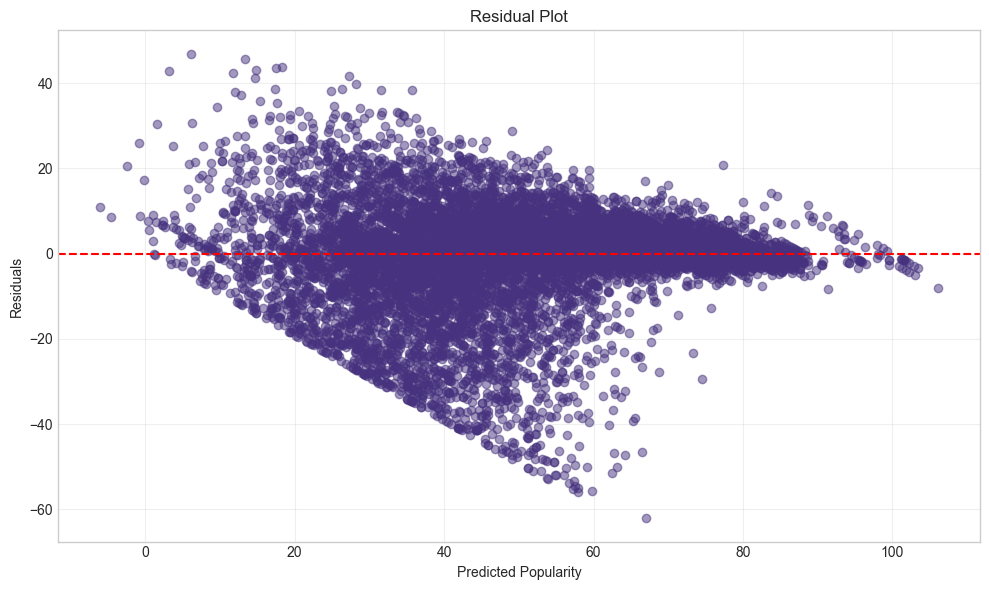


Performing cross-validation...
Cross-validation RMSE: 10.9251 ± 0.0436


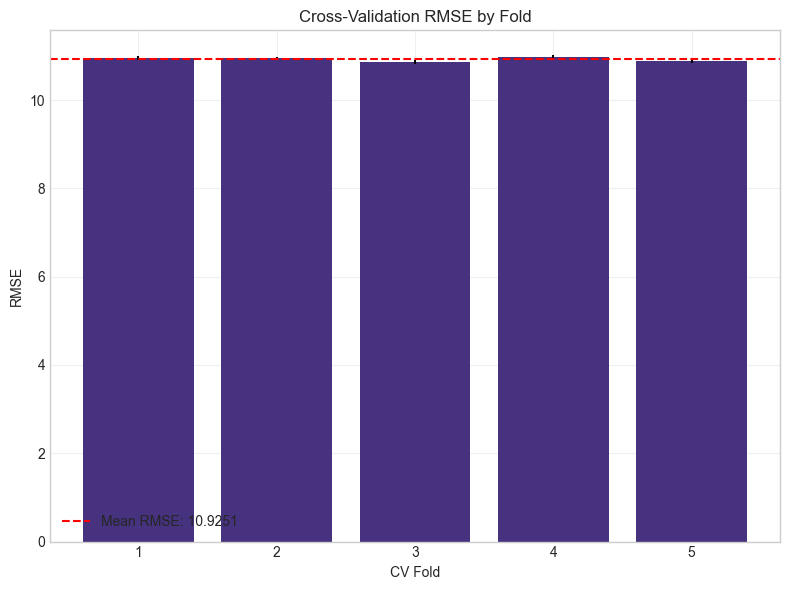


Analyzing feature importance...


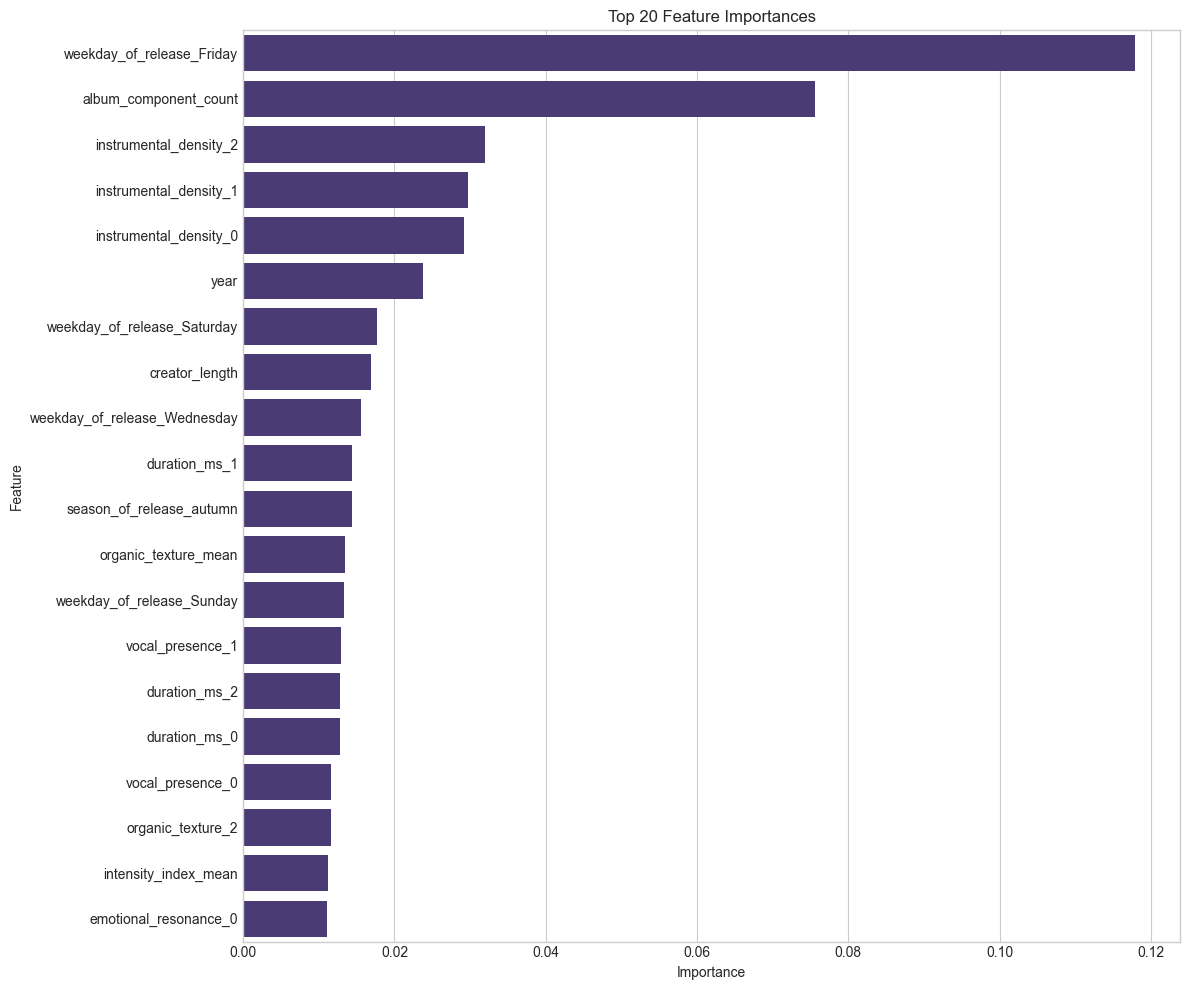

SHAP library not available for additional feature importance visualization

Making predictions...


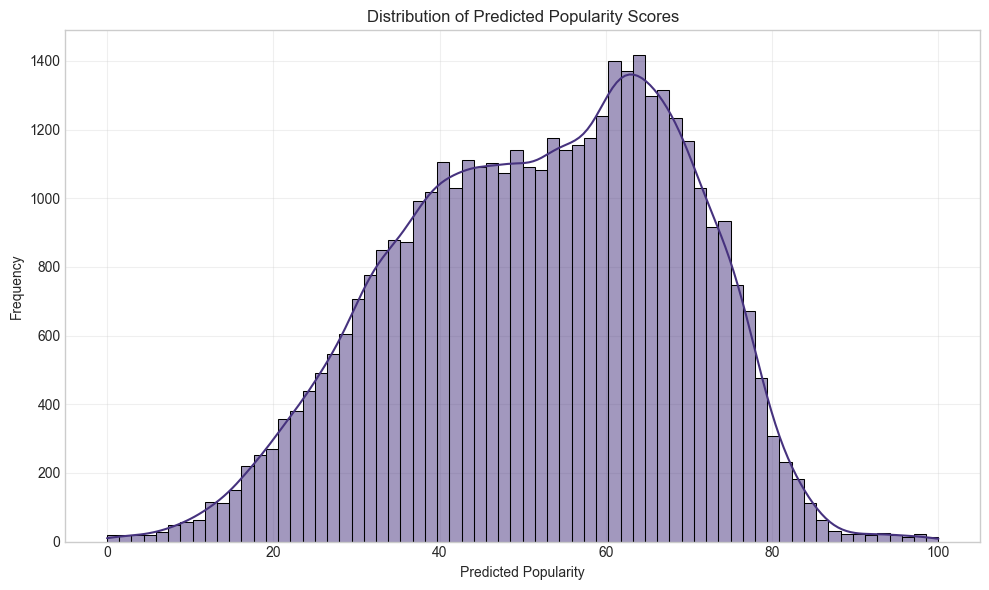

Submission file created: submission5.csv

Done!


In [2]:
# Music Track Popularity Prediction Model
# --------------------------------------
# This notebook preprocesses music track data, trains an XGBoost regression model,
# and generates predictions for track popularity with detailed explanations and visualizations.
# 
# Author: [Your Name]
# Date: April 29, 2025

# --- Import Statements ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# --- Constants and Configuration ---
# Setting a random seed ensures reproducibility across runs
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Data Loading ---
def load_data(train_path='train.csv', test_path='test.csv'):
    """
    Load training and test datasets from CSV files.
    
    Parameters:
    - train_path: Path to the training data CSV
    - test_path: Path to the test data CSV
    
    Returns:
    - X_full: Features from training data 
    - y_full: Target variable (popularity) from training data
    - test_data: Test dataset for predictions
    """
    # Load data from CSV files
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    
    # Extract target variable ('target' column) from training data
    X_full = train_data.drop(['target'], axis=1)  # Features
    y_full = train_data['target']  # Target variable
    
    return X_full, y_full, test_data

# --- Data Exploration ---
def explore_data(X_full, y_full):
    """
    Explore and visualize the dataset to better understand its structure and relationships.
    
    Parameters:
    - X_full: Features dataframe
    - y_full: Target variable series
    """
    print(f"Training data shape: {X_full.shape}")
    
    # Display basic statistics
    print("\nFeature statistics:")
    display(X_full.describe())
    
    # Check for missing values
    missing_values = X_full.isnull().sum()
    missing_percent = (missing_values / len(X_full)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing_values, 
                               'Percentage': missing_percent})
    print("\nMissing values:")
    display(missing_df[missing_df['Missing Values'] > 0])
    
    # Plot target distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(y_full, kde=True)
    plt.title('Distribution of Track Popularity Scores')
    plt.xlabel('Popularity Score')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Check if we have class imbalance (not really applicable for regression, but shows distribution)
    plt.figure(figsize=(10, 6))
    # Create popularity ranges for visualization
    popularity_bins = pd.cut(y_full, bins=10)
    popularity_counts = popularity_bins.value_counts().sort_index()
    popularity_counts.plot(kind='bar')
    plt.title('Distribution of Popularity Scores by Range')
    plt.xlabel('Popularity Range')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Explore audio features correlations
    audio_features = [col for col in X_full.columns if any(x in col for x in ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'beat_frequency'])]
    
    if audio_features:
        plt.figure(figsize=(12, 10))
        correlation = X_full[audio_features].corr()
        mask = np.triu(np.ones_like(correlation, dtype=bool))
        sns.heatmap(correlation, mask=mask, annot=False, cmap='coolwarm', 
                    center=0, linewidths=0.5)
        plt.title('Correlation Between Audio Features')
        plt.tight_layout()
        plt.show()
    
    # Check publication timestamps distribution if available
    if 'publication_timestamp' in X_full.columns:
        X_full['publication_timestamp'] = pd.to_datetime(X_full['publication_timestamp'])
        plt.figure(figsize=(12, 6))
        X_full['publication_timestamp'].dt.year.value_counts().sort_index().plot(kind='bar')
        plt.title('Distribution of Tracks by Publication Year')
        plt.xlabel('Year')
        plt.ylabel('Count')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# --- Data Preprocessing ---
def preprocess_data(df):
    """
    Preprocess the data by extracting features and transforming variables.
    
    Parameters:
    - df: Input dataframe
    
    Returns:
    - data: Processed dataframe with engineered features
    """
    # Make a copy to avoid modifying the original dataframe
    data = df.copy()
    
    # Extract datetime features from publication_timestamp
    # This transforms the timestamp into multiple numerical features that the model can use
    data['publication_timestamp'] = pd.to_datetime(data['publication_timestamp'])
    data['year'] = data['publication_timestamp'].dt.year
    data['month'] = data['publication_timestamp'].dt.month
    data['day'] = data['publication_timestamp'].dt.day
    data['day_of_year'] = data['publication_timestamp'].dt.dayofyear
    data['quarter'] = data['publication_timestamp'].dt.quarter
    
    # Create artist name length feature
    # The length of the creator name might correlate with popularity
    data['creator_length'] = data['creator_collective'].apply(lambda x: len(str(x)))
    
    # Process track_identifier (title) features
    # Title length and word count might influence track popularity
    data['track_identifier_length'] = data['track_identifier'].apply(lambda x: len(str(x)))
    data['track_identifier_word_count'] = data['track_identifier'].apply(lambda x: len(str(x).split()))
    
    # Calculate additional statistics for audio features across tracks
    # These aggregated statistics might capture patterns across different parts of a track
    audio_features = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'beat_frequency']
    
    for feature in audio_features:
        # Get all columns related to this feature across tracks
        cols = [col for col in data.columns if feature in col]
        
        if len(cols) > 1:
            # Calculate mean across tracks
            data[f'{feature}_mean'] = data[cols].mean(axis=1)
            # Calculate standard deviation across tracks
            data[f'{feature}_std'] = data[cols].std(axis=1)
            # Calculate range across tracks
            data[f'{feature}_range'] = data[cols].max(axis=1) - data[cols].min(axis=1)
    
    # Calculate audio feature ratios and interactions
    # Feature interactions can capture more complex relationships
    # Energy to danceability ratio for all tracks
    for i in range(3):  # For tracks 0-2
        # Add small constant (0.001) to avoid division by zero
        data[f'energy_dance_ratio_{i}'] = data[f'intensity_index_{i}'] / (data[f'rhythmic_cohesion_{i}'] + 0.001)
        data[f'dance_energy_product_{i}'] = data[f'intensity_index_{i}'] * data[f'rhythmic_cohesion_{i}']
    
    # Drop columns that shouldn't be used for modeling
    # These are typically identifier columns or redundant data
    drop_columns = ['track_identifier', 'creator_collective', 'publication_timestamp', 
                   'composition_label_0', 'composition_label_1', 'composition_label_2']
    
    # Check if columns exist before dropping to avoid errors
    drop_columns = [col for col in drop_columns if col in data.columns]
    data = data.drop(drop_columns, axis=1)
    
    return data

def handle_outliers(df, columns):
    """
    Handle outliers in numeric columns using the Interquartile Range (IQR) method.
    
    Parameters:
    - df: Input dataframe
    - columns: List of columns to check for outliers
    
    Returns:
    - df_clean: Dataframe with outliers handled
    """
    df_clean = df.copy()
    
    for col in columns:
        # Only process numeric columns
        if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
            # Calculate IQR boundaries
            Q1 = df_clean[col].quantile(0.25)  # First quartile
            Q3 = df_clean[col].quantile(0.75)  # Third quartile
            IQR = Q3 - Q1  # Interquartile range
            
            # Define lower and upper bounds for outliers
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Instead of removing outliers, cap them at the boundaries
            # This preserves the data points while reducing their extreme values
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
            
    return df_clean

def visualize_outlier_handling(df_original, df_clean, column):
    """
    Visualize the effect of outlier handling on a specific column.
    
    Parameters:
    - df_original: Original dataframe
    - df_clean: Dataframe after outlier handling
    - column: Column to visualize
    """
    plt.figure(figsize=(12, 6))
    
    # Create subplot for boxplots
    plt.subplot(1, 2, 1)
    boxplot_data = [df_original[column], df_clean[column]]
    plt.boxplot(boxplot_data, labels=['Original', 'After Handling'])
    plt.title(f'Boxplot of {column}: Before vs After Outlier Handling')
    plt.grid(True, alpha=0.3)
    
    # Create subplot for histograms
    plt.subplot(1, 2, 2)
    plt.hist(df_original[column], alpha=0.5, bins=30, label='Original')
    plt.hist(df_clean[column], alpha=0.5, bins=30, label='After Handling')
    plt.title(f'Distribution of {column}: Before vs After Outlier Handling')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Model Building ---
def build_preprocessor(X_data):
    """
    Build a preprocessing pipeline for feature transformation.
    
    Parameters:
    - X_data: Input features dataframe
    
    Returns:
    - preprocessor: ColumnTransformer object for preprocessing
    - numeric_features: List of numeric feature names
    - categorical_features: List of categorical feature names
    """
    # Identify numeric and categorical columns based on data types
    numeric_features = X_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X_data.select_dtypes(include=['object']).columns.tolist()
    
    # Create preprocessing pipeline for numeric features
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # Fill missing values with median
        ('scaler', StandardScaler())  # Standardize features to mean=0, std=1
    ])
    
    # Create preprocessing pipeline for categorical features
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing values with most frequent value
        ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical variables
    ])
    
    # Combine preprocessing steps into a ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    return preprocessor, numeric_features, categorical_features

def build_model_pipeline(preprocessor):
    """
    Create a model pipeline with preprocessor and XGBoost model.
    
    Parameters:
    - preprocessor: ColumnTransformer object for preprocessing
    
    Returns:
    - model_pipeline: Complete pipeline with preprocessing and model
    """
    # Define the XGBoost model with hyperparameters
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',  # Regression task with squared error loss
        n_estimators=1000,  # Maximum number of trees
        max_depth=6,  # Maximum depth of trees
        learning_rate=0.1,  # Step size shrinkage to prevent overfitting
        subsample=0.8,  # Fraction of samples used for fitting trees
        colsample_bytree=0.8,  # Fraction of features used for fitting trees
        random_state=RANDOM_SEED  # For reproducibility
    )
    
    # Create the full pipeline connecting preprocessor with the model
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', xgb_model)
    ])
    
    return model_pipeline

def train_with_early_stopping(X_train, y_train, X_val, y_val, preprocessor, model_pipeline):
    """
    Train model with early stopping to prevent overfitting.
    
    Parameters:
    - X_train, y_train: Training data and labels
    - X_val, y_val: Validation data and labels
    - preprocessor: ColumnTransformer for preprocessing
    - model_pipeline: Pipeline with preprocessor and model
    
    Returns:
    - model_pipeline: Trained model pipeline
    """
    # Process training and validation data using the preprocessor
    preprocessed_train = preprocessor.fit_transform(X_train)
    preprocessed_val = preprocessor.transform(X_val)
    
    # Create a separate XGBoost model with early stopping for this training
    early_stop_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,  # Slightly lower learning rate for better convergence
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        early_stopping_rounds=10  # Stop if no improvement for 10 consecutive rounds
    )
    
    # Train with early stopping using validation data
    early_stop_model.fit(
        preprocessed_train, y_train,
        eval_set=[(preprocessed_val, y_val)],  # Validation set for early stopping
        verbose=False  # Suppress training output
    )
    
    # Get the best number of estimators determined by early stopping
    best_iteration = early_stop_model.best_iteration
    
    # Update pipeline model with the best number of estimators
    # If early stopping didn't find a best iteration, keep the original value
    model_pipeline.named_steps['model'].n_estimators = best_iteration if best_iteration > 0 else model_pipeline.named_steps['model'].n_estimators
    
    # Train the pipeline with the optimized number of estimators
    model_pipeline.fit(X_train, y_train)
    
    return model_pipeline

# --- Evaluation ---
def evaluate_model(model, X_val, y_val):
    """
    Evaluate model performance on validation set.
    
    Parameters:
    - model: Trained model
    - X_val, y_val: Validation data and labels
    
    Returns:
    - rmse: Root Mean Squared Error
    - mae: Mean Absolute Error
    - r2: R-squared score
    """
    # Make predictions on validation data
    y_pred = model.predict(X_val)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))  # Root Mean Squared Error
    mae = mean_absolute_error(y_val, y_pred)  # Mean Absolute Error
    r2 = r2_score(y_val, y_pred)  # Coefficient of determination
    
    # Print evaluation results
    print(f"Validation RMSE: {rmse:.4f}")
    print(f"Validation MAE: {mae:.4f}")
    print(f"Validation R^2: {r2:.4f}")
    
    # Visualize predictions vs actual values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_val, y_pred, alpha=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    plt.xlabel('Actual Popularity')
    plt.ylabel('Predicted Popularity')
    plt.title('Predicted vs Actual Popularity Scores')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot residuals
    residuals = y_val - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Popularity')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return rmse, mae, r2

def perform_cross_validation(model, X, y, cv=5):
    """
    Perform cross-validation to assess model performance.
    
    Parameters:
    - model: Model pipeline
    - X, y: Features and target
    - cv: Number of cross-validation folds
    
    Returns:
    - cv_rmse: Mean RMSE from cross-validation
    """
    # Perform cross-validation with RMSE as metric
    cv_scores = cross_val_score(model, X, y, 
                              cv=cv, scoring='neg_root_mean_squared_error')
    
    # Convert negative RMSE to positive (sklearn always maximizes scores)
    cv_rmse = -cv_scores.mean()
    cv_rmse_std = cv_scores.std()
    
    print(f"Cross-validation RMSE: {cv_rmse:.4f} ± {cv_rmse_std:.4f}")
    
    # Visualize cross-validation results
    plt.figure(figsize=(8, 6))
    plt.bar(range(1, len(cv_scores) + 1), -cv_scores, yerr=cv_rmse_std)
    plt.axhline(y=cv_rmse, color='r', linestyle='--', label=f'Mean RMSE: {cv_rmse:.4f}')
    plt.xlabel('CV Fold')
    plt.ylabel('RMSE')
    plt.title('Cross-Validation RMSE by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return cv_rmse

# --- Feature Importance Analysis ---
def analyze_feature_importance(preprocessor, X_processed, y_full, numeric_features, categorical_features, top_n=20):
    """
    Analyze and plot feature importance.
    
    Parameters:
    - preprocessor: ColumnTransformer for preprocessing
    - X_processed: Processed features
    - y_full: Target variable
    - numeric_features: List of numeric feature names
    - categorical_features: List of categorical feature names
    - top_n: Number of top features to display
    
    Returns:
    - final_model: Trained XGBoost model
    - feature_names: List of feature names after preprocessing
    """
    # Train the model directly on preprocessed data to get feature importance
    preprocessed_train = preprocessor.fit_transform(X_processed)
    
    # Create and train a final XGBoost model
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED
    )
    
    # Train the final model
    final_model.fit(preprocessed_train, y_full)
    
    # Get feature names for visualization
    feature_names = numeric_features.copy()
    if categorical_features:
        # Get one-hot encoded feature names for categorical features
        ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
        feature_names.extend(ohe_feature_names)
    
    # Create feature importance dictionary for better visualization
    feature_importance = {
        'Feature': [feature_names[i] if i < len(feature_names) else f"Feature_{i}" for i in range(len(final_model.feature_importances_))],
        'Importance': final_model.feature_importances_
    }
    fi_df = pd.DataFrame(feature_importance).sort_values('Importance', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(12, 10))
    top_features = fi_df.head(top_n)
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # SHAP values for more detailed feature importance (if shap is available)
    try:
        import shap
        explainer = shap.Explainer(final_model)
        shap_values = explainer(preprocessed_train)
        
        plt.figure(figsize=(12, 10))
        shap.summary_plot(shap_values, feature_names=feature_names, plot_size=(12, 10))
        plt.tight_layout()
        plt.savefig('shap_summary.png')
        plt.show()
    except:
        print("SHAP library not available for additional feature importance visualization")
    
    return final_model, feature_names

# --- Prediction ---
def make_predictions(model, test_data, output_file='submission5.csv'):
    """
    Make predictions on test data and create submission file.
    
    Parameters:
    - model: Trained model
    - test_data: Test dataset
    - output_file: Output CSV filename
    
    Returns:
    - submission: Dataframe with predictions
    """
    # Make predictions on test data
    test_predictions = model.predict(test_data)
    
    # Prepare submission file
    submission = pd.DataFrame({
        'id': test_data['id'] if 'id' in test_data.columns else range(len(test_data)),
        'target': test_predictions
    })
    
    # Ensure predictions are within the valid range (0-100)
    submission['target'] = submission['target'].clip(0, 100)
    
    # Visualize prediction distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(submission['target'], kde=True)
    plt.title('Distribution of Predicted Popularity Scores')
    plt.xlabel('Predicted Popularity')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Save submission file
    submission.to_csv(output_file, index=False)
    print(f"Submission file created: {output_file}")
    
    return submission

# --- Main Execution ---
def main():
    # Load data
    print("Loading data...")
    X_full, y_full, test_data = load_data()
    
    # Explore data
    print("\nExploring data...")
    explore_data(X_full, y_full)
    
    # Preprocess data
    print("\nPreprocessing data...")
    X_processed = preprocess_data(X_full)
    test_processed = preprocess_data(test_data)
    
    # Handle outliers in numeric columns of training data
    print("\nHandling outliers...")
    numeric_cols = X_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
    X_processed_clean = handle_outliers(X_processed, numeric_cols)
    
    # Visualize effect of outlier handling on a few key columns
    for col in numeric_cols[:3]:  # Show first 3 numeric columns as examples
        visualize_outlier_handling(X_processed, X_processed_clean, col)
    
    # Split data for training and validation
    print("\nSplitting data...")
    X_train, X_val, y_train, y_val = train_test_split(
        X_processed_clean, y_full, test_size=0.2, random_state=RANDOM_SEED
    )
    
    # Build preprocessor and model pipeline
    print("\nBuilding model pipeline...")
    preprocessor, numeric_features, categorical_features = build_preprocessor(X_processed_clean)
    model_pipeline = build_model_pipeline(preprocessor)
    
    # Train model with early stopping
    print("\nTraining model...")
    model_pipeline = train_with_early_stopping(
        X_train, y_train, X_val, y_val, preprocessor, model_pipeline
    )
    
    # Evaluate model
    print("\nEvaluating model...")
    rmse, mae, r2 = evaluate_model(model_pipeline, X_val, y_val)
    
    # Perform cross-validation
    print("\nPerforming cross-validation...")
    cv_rmse = perform_cross_validation(model_pipeline, X_processed_clean, y_full)
    
    # Analyze feature importance
    print("\nAnalyzing feature importance...")
    final_model, feature_names = analyze_feature_importance(
        preprocessor, X_processed_clean, y_full, numeric_features, categorical_features
    )
    
    # Make predictions on test set
    print("\nMaking predictions...")
    submission = make_predictions(model_pipeline, test_processed, output_file='submission5.csv')
    
    print("\nDone!")
    return model_pipeline, submission

if __name__ == "__main__":
    main()